In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("SuperstoreSales_Cleaned.csv")

In [5]:
sns.set_theme(style = 'whitegrid')

In [9]:
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [11]:
df.shape

(9977, 13)

In [172]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
profit_margin = (total_profit / total_sales) * 100
total_orders = df.shape[0]
Avg_discount = df['Discount'].mean()
Average_Discount = Avg_discount * 100

In [174]:
print(f"total_sales = {total_sales}")
print(f"total_profit = {total_profit}")
print(f"total_orders = {total_orders}")
print(f"Profit_margin = {profit_margin}")
print(f"Average_Discount = {Average_Discount}")

total_sales = 2296195.5903
total_profit = 286241.4226
total_orders = 9977
Profit_margin = 12.465898976950927
Average_Discount = 15.627844041294981


In [176]:
formatted_sales = f'₹{total_sales/1_000_000:.2f}M'
formatted_profit = f'₹{total_profit/1_000_000:.2f}M'
formatted_orders = f'{total_orders:,}'
formatted_profit_margin = f'{profit_margin:.2f}%'
formatted_Average_Discount = f'{Average_Discount:.2f}%'

print(f"Formatted_total_sales = {formatted_sales}")
print(f"total_profit = {formatted_profit}")
print(f"total_orders = {formatted_orders}")
print(f"Profit_margin = {formatted_profit_margin}")
print(f"Average_Discount = {formatted_Average_Discount}")

Formatted_total_sales = ₹2.30M
total_profit = ₹0.29M
total_orders = 9,977
Profit_margin = 12.47%
Average_Discount = 15.63%


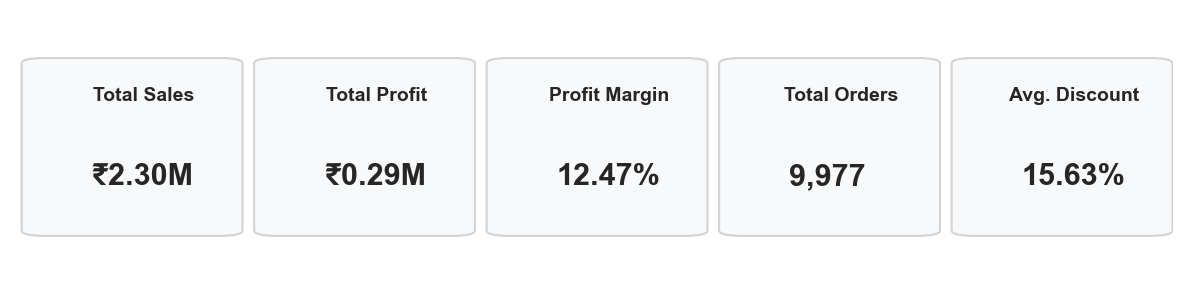

In [178]:
from matplotlib.patches import FancyBboxPatch

plt.figure(figsize = (15,3.5))

# plt.suptitle( 'Superstore Profitability Analysis Dashboard ',
#              fontsize = 24,
#              fontweight = 'bold',
#              y = 0.98
# )

plt.axis('off')

kpis = {
    "Total Sales": formatted_sales,
    "Total Profit": formatted_profit,
    "Profit Margin": formatted_profit_margin,
    "Total Orders": formatted_orders,
    "Avg. Discount": formatted_Average_Discount
}

for i, (title,value) in enumerate(kpis.items()):

    x = 0.05 + i * 0.2

    card = FancyBboxPatch(
        (x - 0.02 , 0.18),
        0.15,
        0.62,
        boxstyle = 'round,pad = 0.02',
        facecolor = '#F8F9FA',
        edgecolor = 'Lightgray',
        linewidth = 1.5
    )

    plt.gca().add_patch(card)

    plt.text(
        x + 0.065, 
        0.68,
        title,
        ha = 'center',
        va = 'center',
        fontsize = 14,
        fontweight = 'bold'
    )

    plt.text(
        x + 0.02 ,
        0.35,
        value,
        # ha = 'center',
        # va = 'center',
        fontsize = 22,
        fontweight = 'bold'
    )


plt.show()

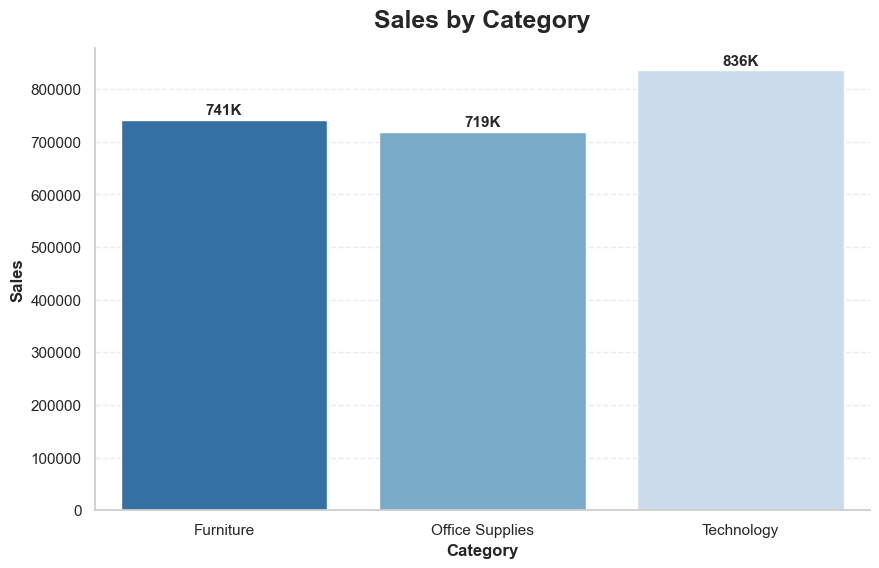

In [124]:
category_summary = df.groupby('Category').agg({'Sales':'sum','Profit':'sum'}).reset_index()
category_summary

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data= category_summary,
    x='Category',
    y='Sales',
    hue = 'Category',
    palette='Blues_r',
    legend = False
)

plt.title('Sales by Category', fontsize = 18, fontweight = 'bold', pad = 15)
plt.xlabel('Category', fontsize = 12, fontweight = 'bold')
plt.ylabel('Sales', fontsize = 12, fontweight = 'bold')

for i,value in enumerate(category_summary['Sales']):
    ax.text(
        i,
        value + 10000,
        f"{value/1000:.0f}K",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid (axis = 'y', linestyle = '--', alpha = 0.4 )

plt.show()



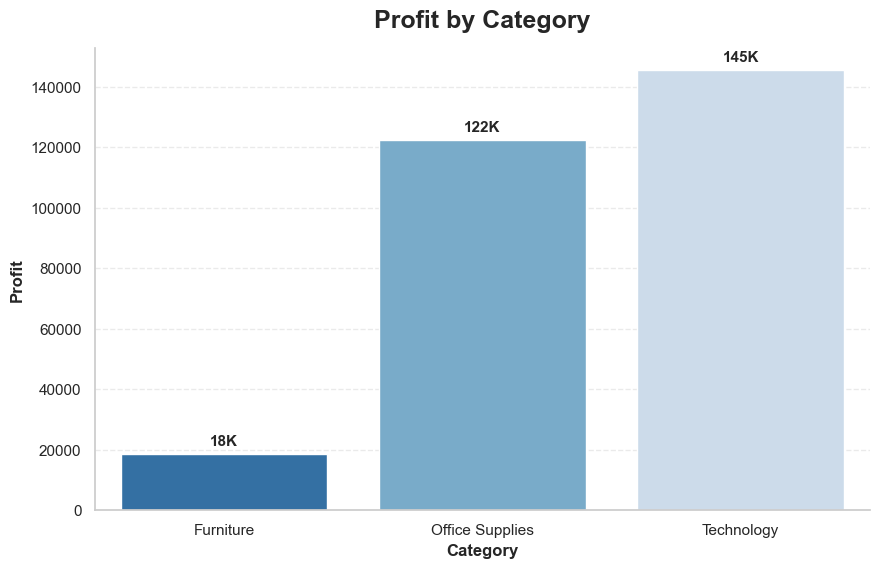

In [144]:
plt.figure(figsize = (10,6))

ax = sns.barplot(
    data = category_summary,
    x = 'Category',
    y = 'Profit',
    hue = 'Category',
    palette = 'Blues_r',
    legend = False
)

plt.title('Profit by Category', fontsize = 18, fontweight = 'bold', pad = 15)
plt.xlabel('Category', fontsize = 12, fontweight = 'bold')
plt.ylabel('Profit', fontsize = 12, fontweight = 'bold')

for i, value in enumerate(category_summary['Profit']):
     ax.text(
        i,
        value + 3000,
        f"{value/1000:.0f}K",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis = 'y', linestyle = '--', alpha = 0.4)
plt.show()
    

In [29]:
tables_df = df[df['Sub-Category'] == 'Tables']
tables_df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
10,Standard Class,Consumer,United States,Los Angeles,California,90032,West,Furniture,Tables,1706.1840,9,0.20,85.3092
24,Standard Class,Consumer,United States,Orem,Utah,84057,West,Furniture,Tables,1044.6300,3,0.00,240.2649
117,Standard Class,Consumer,United States,Seattle,Washington,98103,West,Furniture,Tables,787.5300,3,0.00,165.3813
125,Standard Class,Consumer,United States,Bloomington,Illinois,61701,Central,Furniture,Tables,617.7000,6,0.50,-407.6820


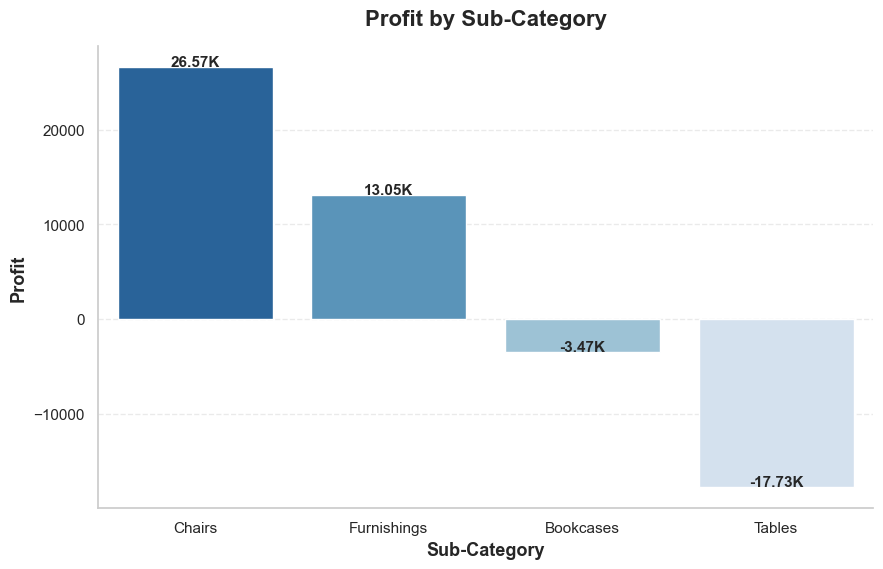

In [160]:
furniture_df = df[df['Category'] == 'Furniture']

profit_by_subcategory = furniture_df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values(by = 'Profit', ascending = False)
profit_by_subcategory

plt.figure(figsize = (10,6))

ax = sns.barplot(
    data = profit_by_subcategory,
    x = 'Sub-Category',
    y = 'Profit',
    hue = 'Sub-Category',
    palette = 'Blues_r'
)

for i, value in enumerate(profit_by_subcategory['Profit']):
     ax.text(
        i,
        value + 100,
        f"{value/1000:.2f}K",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


plt.title('Profit by Sub-Category', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Sub-Category', fontsize = 13, fontweight = 'bold')
plt.ylabel('Profit', fontsize = 13, fontweight = 'bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid (axis = 'y', linestyle = '--', alpha = 0.4 )

plt.show()

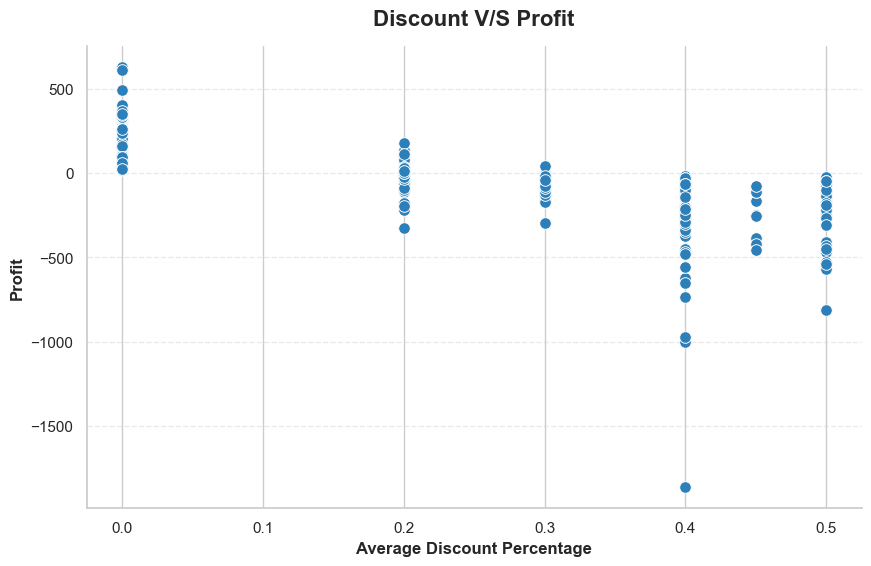

In [136]:
plt.figure(figsize = (10,6))

ax = sns.scatterplot(
    data = tables_df,
    x = 'Discount',
    y = 'Profit',
    color = '#2C7FB8',
    s = 70 # size of each point
)

plt.title('Discount V/S Profit', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Average Discount Percentage', fontsize = 12, fontweight = 'bold')
plt.ylabel('Profit', fontsize = 12, fontweight = 'bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.grid (axis = 'y', linestyle = '--', alpha = 0.4 )
plt.show()

In [95]:
profit_by_region = tables_df.groupby('Region')['Profit'].sum().reset_index().sort_values(by = 'Profit', ascending = False)
profit_by_region

,Region,Profit
3,West,1482.6073
0,Central,-3559.6504
2,South,-4623.0579
1,East,-11025.3801


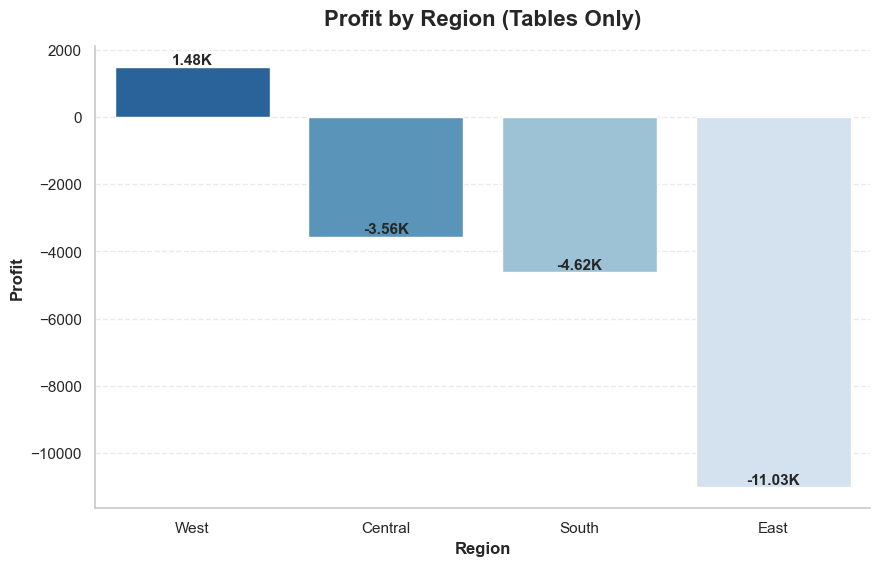

In [163]:
plt.figure(figsize = (10,6))

ax = sns.barplot(
    data = profit_by_region,
    x = 'Region',
    y = 'Profit',
    hue = 'Region',
    palette = 'Blues_r'
)
    
for i, value in enumerate(profit_by_region['Profit']):
     ax.text(
        i,
        value + 100,
        f"{value/1000:.2f}K",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )
    
plt.title('Profit by Region (Tables Only)', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Region', fontsize = 12, fontweight = 'bold')
plt.ylabel('Profit', fontsize = 12, fontweight = 'bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid (axis = 'y', linestyle = '--', alpha = 0.4 )

plt.show()

In [106]:
profit_by_segments = tables_df.groupby('Segment')['Profit'].sum().reset_index().sort_values(by = 'Profit', ascending = False)
profit_by_segments

,Segment,Profit
2,Home Office,-3090.9447
1,Corporate,-4906.4986
0,Consumer,-9728.0378


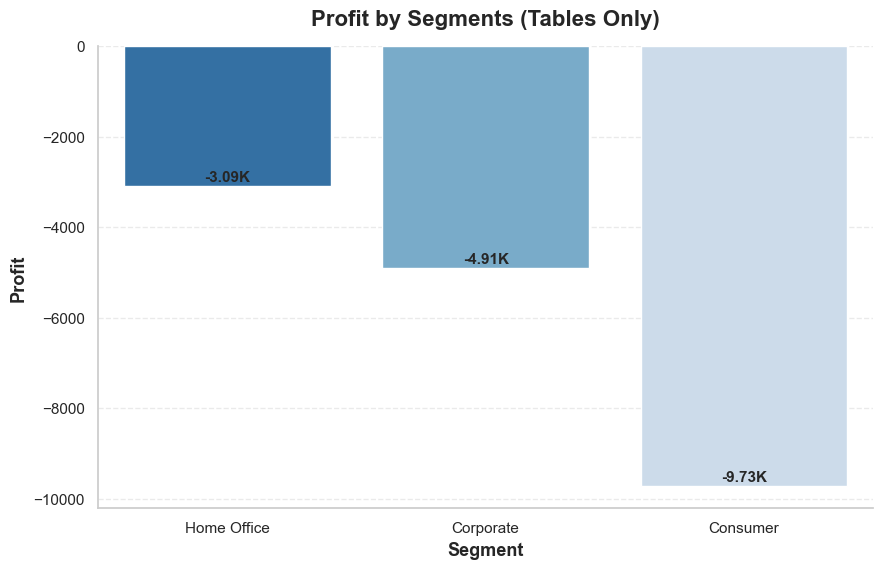

In [165]:
plt.figure(figsize = (10,6))

ax = sns.barplot(
    data = profit_by_segments,
    x = 'Segment',
    y = 'Profit',
    hue = 'Segment',
    palette = 'Blues_r'
)

for i, value in enumerate(profit_by_segments['Profit']):
     ax.text(
        i,
        value + 100,
        f"{value/1000:.2f}K",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


plt.title('Profit by Segments (Tables Only)', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Segment', fontsize = 13, fontweight = 'bold')
plt.ylabel('Profit', fontsize = 13, fontweight = 'bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid (axis = 'y', linestyle = '--', alpha = 0.4 )

plt.show()

In [118]:
profit_by_shipmode = tables_df.groupby('Ship Mode')['Profit'].sum().reset_index().sort_values(by = 'Profit', ascending = False)
profit_by_shipmode 

,Ship Mode,Profit
1,Same Day,-1129.4225
0,First Class,-1365.3665
2,Second Class,-3320.6799
3,Standard Class,-11910.0122


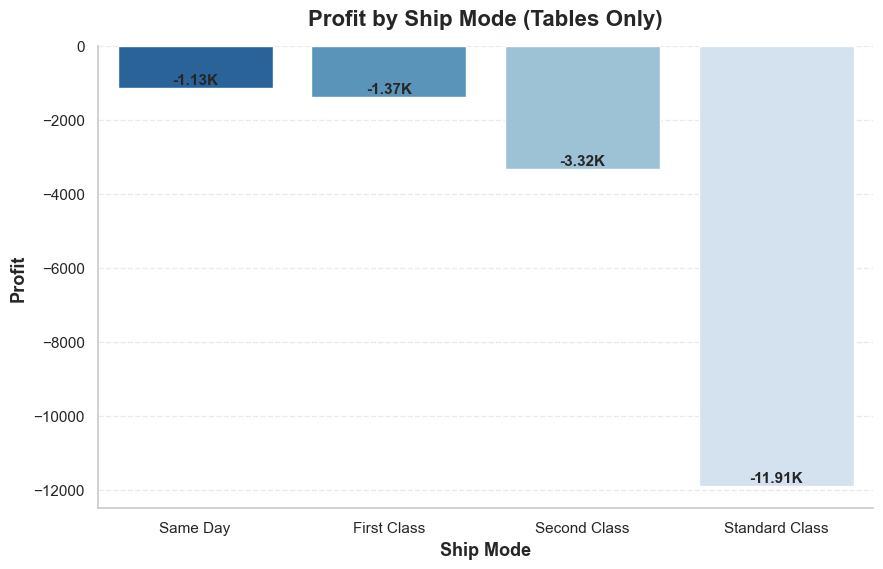

In [167]:
plt.figure(figsize = (10,6))

ax = sns.barplot(
    data = profit_by_shipmode,
    x = 'Ship Mode',
    y = 'Profit',
    hue = 'Ship Mode',
    palette = 'Blues_r'
)

for i, value in enumerate(profit_by_shipmode['Profit']):
     ax.text(
        i,
        value + 100,
        f"{value/1000:.2f}K",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )


plt.title('Profit by Ship Mode (Tables Only)', fontsize = 16, fontweight = 'bold', pad = 15)
plt.xlabel('Ship Mode', fontsize = 13, fontweight = 'bold')
plt.ylabel('Profit', fontsize = 13, fontweight = 'bold')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid (axis = 'y', linestyle = '--', alpha = 0.4 )

plt.show()